In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from mad.configs.ballistic_objects import titan1_stages, titan2_stages, minuteman_stages
from mad.configs.warheads import B53_warhead
from mad.configs.planets import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, PayloadConfig
from mad.guidances import TabulatedBallistic, NoGuidance
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [4]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in titan1_stages]

missile_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_fine")
warhead_guidance = NoGuidance(planet=earth, target=target)

payload_cfg = PayloadConfig(**B53_warhead)
payload_cfg.guidance = warhead_guidance

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payload=payload_cfg, 
                                     n_RVs = 5, 
                                     RV_separation_interval=5.0)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Burned Fraction: 0.00.

In [5]:
dt = 1.0
max_time = 20_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

results = sim.results


17:39:21 | INFO     | Simulation   | Starting simulation.
17:39:21 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
17:39:21 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
17:39:21 | INFO     | Simulation   | New objects spawned this step: ['Stage1']
17:39:21 | INFO     | Missile      | Titan I released payload B53Warhead_1 at 153.00.
17:39:21 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_1']
17:39:21 | INFO     | Missile      | Titan I released payload B53Warhead_2 at 159.00.
17:39:21 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_2']
17:39:21 | INFO     | Missile      | Titan I released payload B53Warhead_3 at 165.00.
17:39:21 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_3']
17:39:21 | INFO     | Missile      | Titan I released payload B53Warhead_4 at 171.00.
17:39:21 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_4']
17:39:21 | INFO     | Missi

In [6]:
results

,t,name,_id,position,velocity,posx,posz,speed,altitude,gamma
0,0.0,Titan I,BallisticMissile_Titan I_4,"[-45108.1856052648, 6370850.30994226, 0.0]","[0.0, 0.0, 0.0]",-45108.185605,6.370850e+06,0.000000,6.371010e+06,1.553343
1,1.0,Titan I,BallisticMissile_Titan I_4,"[-45108.01743160817, 6370854.492456477, 0.0]","[0.33634711521166716, 8.365034876078095, 0.0]",-45108.017432,6.370854e+06,8.371794,6.371014e+06,1.553343
2,2.0,Titan I,BallisticMissile_Titan I_4,"[-45107.32112932746, 6370867.092886605, 0.0]","[1.0562567538514847, 16.835846042542947, 0.0]",-45107.321129,6.370867e+06,16.868948,6.371027e+06,1.521933
3,3.0,Titan I,BallisticMissile_Titan I_4,"[-45105.71368908595, 6370888.212104681, 0.0]","[2.1586226819328753, 25.402631189974468, 0.0]",-45105.713689,6.370888e+06,25.494182,6.371048e+06,1.504352
4,4.0,Titan I,BallisticMissile_Titan I_4,"[-45102.818685135935, 6370917.941606943, 0.0]","[3.631384843543225, 34.05644667267245, 0.0]",-45102.818685,6.370918e+06,34.249504,6.371078e+06,1.480045
...,...,...,...,...,...,...,...,...,...,...
2957,663.0,Stage2,Projectile_Stage2_11,"[933172.7198186493, 6302687.1705738995, 0.0]","[-12.545306963219211, -84.75500545402592, 0.0]",933172.719819,6.302687e+06,85.678443,6.371395e+06,NaN
2958,664.0,Stage2,Projectile_Stage2_11,"[933160.2033298444, 6302602.611607321, 0.0]","[-12.480131383957874, -84.31199304554943, 0.0]",933160.203330,6.302603e+06,85.230663,6.371310e+06,NaN
2959,665.0,Stage2,Projectile_Stage2_11,"[933147.7517040396, 6302518.4933802085, 0.0]","[-12.415623400752652, -83.87381485132532, 0.0]",933147.751704,6.302518e+06,84.787762,6.371225e+06,NaN
2960,666.0,Stage2,Projectile_Stage2_11,"[933135.3642768745, 6302434.811098155, 0.0]","[-12.351776049754374, -83.44038773133317, 0.0]",933135.364277,6.302435e+06,84.349657,6.371140e+06,NaN


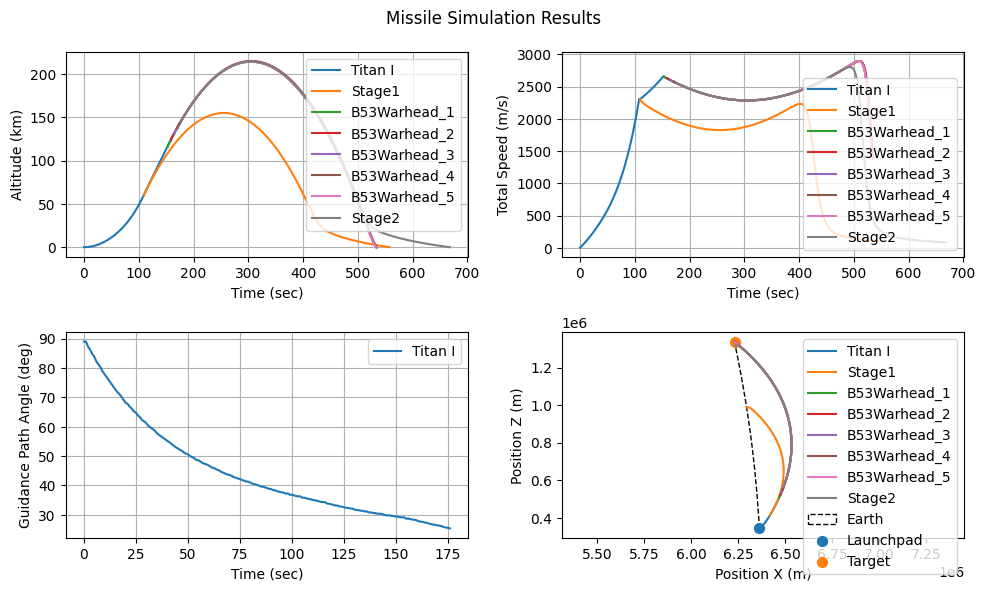

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    # ax[2].plot(result["time"], result["energy"] / 1000_000, label=obj)
    if "gamma" in result and len(result["gamma"]) > 0:
        ax[2].plot(result["time"], nap.degrees(result["gamma"]), label=obj)
    ax[3].plot(result["posx"], result["posz"], label=obj)


ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

# ax[2].set_xlabel("Time (sec)")
# ax[2].set_ylabel("Energy (MJ/kg)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()

fig.suptitle("Missile Simulation Results")
fig.tight_layout(pad=1.2)